In [4]:
# Retail Sales Data Analysis
### Author: Paul Muindi
### Tools: Python, Pandas, Matplotlib

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
## Loading the data
df = pd.read_csv("../data/retail_sales.csv")
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [7]:
##Inspecting the data
df.shape

(1000, 9)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [10]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [9]:
## Convert Date folder from object to data
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [11]:
## Data Cleaning
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
## Compute Total Revenue
df["Total Amount"].sum()

np.int64(456000)

In [14]:
## Sales by Category
category_sales = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

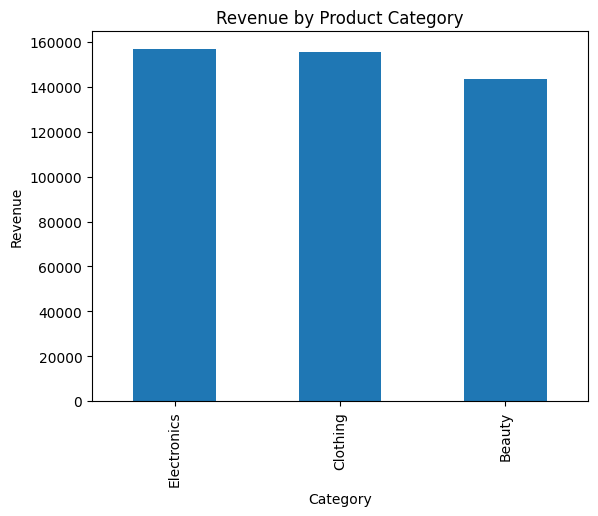

In [51]:
## Visualization
category_sales.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.savefig("../visuals/category_sales.png")
plt.show()

Business categories don't have a wide range in total revenue. Electronics category generated the highest revenue with a total of $156,905.00, followed closely by clothing category with a total of $155,580.00. Beauty category recorded a total revenue of $143,515.00

In [16]:
## Save
plt.savefig("../visuals/category_sales.png")

<Figure size 640x480 with 0 Axes>

In [17]:
(df["Quantity"] * df["Price per Unit"]).head()

0     150
1    1000
2      30
3     500
4     100
dtype: int64

In [18]:
((df["Quantity"] * df["Price per Unit"]) == df["Total Amount"]).all()

np.True_

In [19]:
## Average transaction value
df["Total Amount"].mean()

np.float64(456.0)

In [20]:
## Sales over time
df["Month"] = df["Date"].dt.to_period("M")

In [21]:
monthly_sales = df.groupby("Month")["Total Amount"].sum()

monthly_sales

Month
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

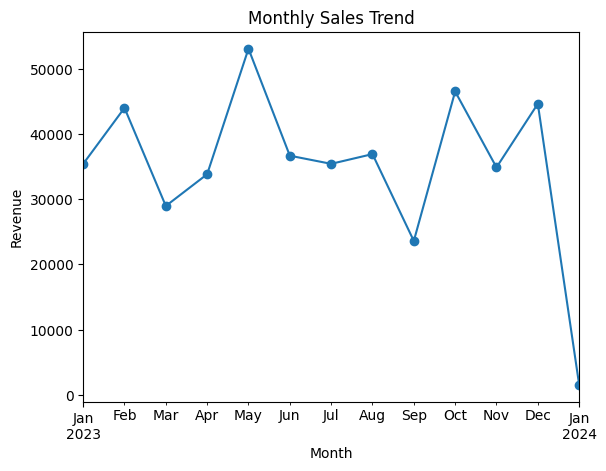

In [52]:
monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.savefig("../visuals/monthly_sales_trend.png")
plt.show()

Sales show a gradual flactuation over time, suggesting a flactuating demand.
Peak revenue occurred in May, likely due to seasonal shopping trends.

In [23]:
plt.savefig("../visuals/monthly_sales_trend.png")

<Figure size 640x480 with 0 Axes>

In [24]:
## Revenue by gender
revenue_by_gender = df.groupby("Gender")["Total Amount"].sum()
revenue_by_gender

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

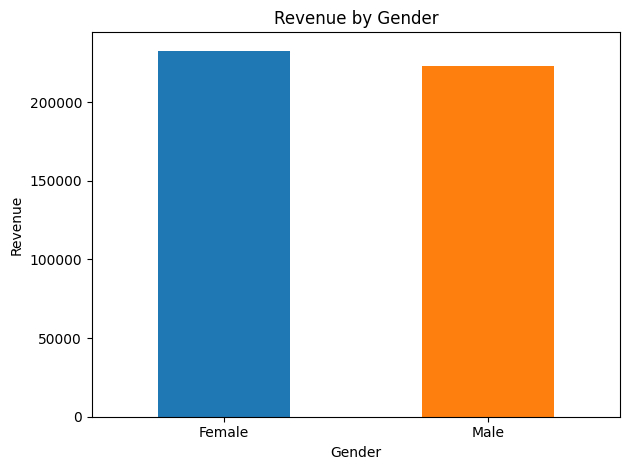

In [53]:

revenue_by_gender.plot(kind="bar", color=["#1f77b4", "#ff7f0e"])  # blue & orange for style
plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue")
plt.xticks(rotation=0)  # keep labels horizontal
plt.tight_layout()
plt.savefig("../visuals/revenue_by_gender.png")
plt.show()

Females generated a relatively higher total revenue of $232,840.00 compared to Males' $223,160.00

In [26]:
plt.savefig("../visuals/revenue_by_gender.png")

<Figure size 640x480 with 0 Axes>

In [40]:
## Age group analysis
# Define bins and labels
bins = [0, 18, 25, 35, 45, 60, 100]
labels = ["<18", "18-25", "26-35", "36-45", "46-60", "60+"]

# Create Age Group column
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

In [41]:
revenue_by_age = df.groupby("Age Group")["Total Amount"].sum()
revenue_by_age

C:\Users\A'nes\AppData\Local\Temp\ipykernel_2788\187136429.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_by_age = df.groupby("Age Group")["Total Amount"].sum()


Age Group
<18       11215
18-25     73335
26-35     98480
36-45     91870
46-60    147875
60+       33225
Name: Total Amount, dtype: int64

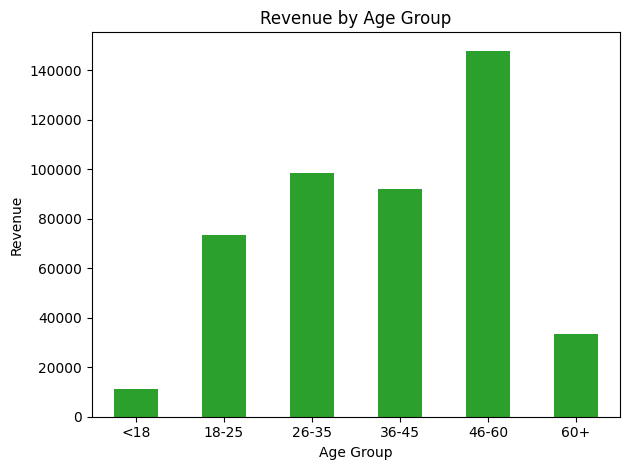

In [54]:
revenue_by_age.plot(kind="bar", color="#2ca02c")  # nice green for style
plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../visuals/revenue_by_age_group.png")
plt.show()

Age group 46-60 generated the highest total revenue with $147,875.00. Age groups <18 and 60+ generated the least revenues with $11,215.00 and $33,225.00 respectively.

In [30]:
plt.savefig("../visuals/revenue_by_age_group.png")

<Figure size 640x480 with 0 Axes>

In [31]:
## Top Spending Customers
top_customers = df.groupby("Customer ID")["Total Amount"].sum().sort_values(ascending=False)
top_customers.head(10)  # Show the top 10

Customer ID
CUST487    2000
CUST476    2000
CUST773    2000
CUST503    2000
CUST093    2000
CUST089    2000
CUST946    2000
CUST157    2000
CUST155    2000
CUST420    2000
Name: Total Amount, dtype: int64

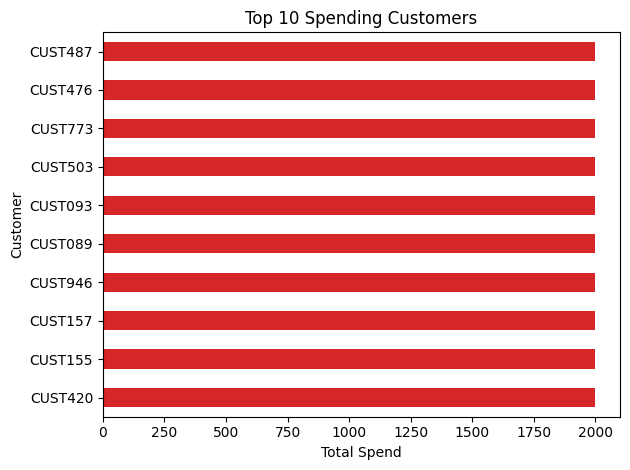

In [55]:
top_customers.head(10).plot(kind="barh", color="#d62728")  # strong red for impact
plt.title("Top 10 Spending Customers")
plt.xlabel("Total Spend")
plt.ylabel("Customer")
plt.gca().invert_yaxis()  # Highest spender on top
plt.tight_layout()
plt.savefig("../visuals/top_spending_customers.png")
plt.show()

All of the ten highest spenders spent the same amount, $2,000.00.

In [33]:
plt.savefig("../visuals/top_spending_customers.png")

<Figure size 640x480 with 0 Axes>

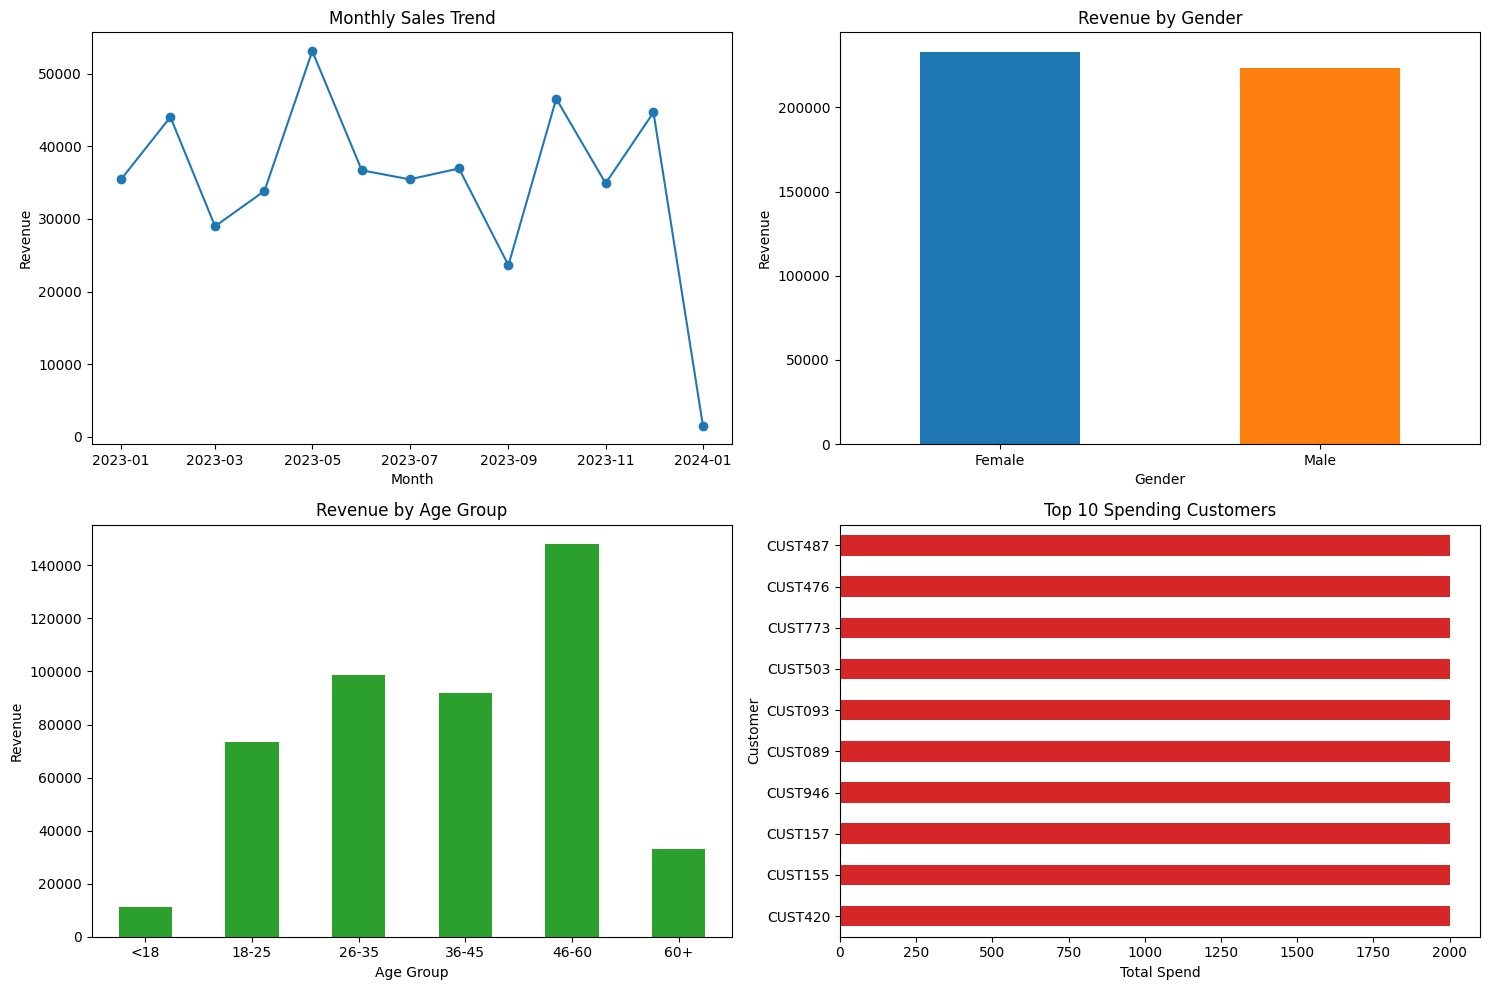

In [61]:
## Dashboard

# Set figure size
fig, axs = plt.subplots(2, 2, figsize=(15, 10))  # 2x2 grid

# 1 Monthly Sales Trend

axs[0, 0].plot(monthly_sales, marker='o', color="#1f77b4")
axs[0, 0].set_title("Monthly Sales Trend")
axs[0, 0].set_xlabel("Month")
axs[0, 0].set_ylabel("Revenue")

# 2 Revenue by Gender
revenue_by_gender.plot(kind="bar", ax=axs[0, 1], color=["#1f77b4", "#ff7f0e"])
axs[0, 1].set_title("Revenue by Gender")
axs[0, 1].set_xlabel("Gender")
axs[0, 1].set_ylabel("Revenue")
axs[0, 1].tick_params(axis='x', rotation=0)

# 3 Revenue by Age Group
revenue_by_age.plot(kind="bar", ax=axs[1, 0], color="#2ca02c")
axs[1, 0].set_title("Revenue by Age Group")
axs[1, 0].set_xlabel("Age Group")
axs[1, 0].set_ylabel("Revenue")
axs[1, 0].tick_params(axis='x', rotation=0)

#  Top Spending Customers
top_customers.head(10).plot(kind="barh", ax=axs[1, 1], color="#d62728")
axs[1, 1].set_title("Top 10 Spending Customers")
axs[1, 1].set_xlabel("Total Spend")
axs[1, 1].set_ylabel("Customer")
axs[1, 1].invert_yaxis()  # Highest spender on top

plt.tight_layout()
plt.savefig("../visuals/retail_sales_dashboard.png")
plt.show()

A Dashboard showing all the visuals.

In [39]:
plt.savefig("../visuals/retail_sales_dashboard.png")

<Figure size 640x480 with 0 Axes>

The following are interactive dashboards on the same data:

In [36]:
import plotly.express as px
import plotly.graph_objects as go

In [37]:
fig_monthly = px.line(
    monthly_sales.reset_index(),
    x="Month",
    y="Total Amount",
    title="Monthly Sales Trend",
    markers=True
)
fig_monthly.update_layout(xaxis_title="Month", yaxis_title="Revenue")
fig_monthly.show()

In [38]:
fig_gender = px.bar(
    revenue_by_gender.reset_index(),
    x="Gender",
    y="Total Amount",
    title="Revenue by Gender",
    color="Gender",
    color_discrete_map={"Male":"#1f77b4", "Female":"#ff7f0e"}
)
fig_gender.show()

In [43]:
fig_age = px.bar(
    revenue_by_age.reset_index(),
    x="Age Group",
    y="Total Amount",
    title="Revenue by Age Group",
)
fig_age.show()

In [50]:
fig_top_customers = px.bar(
    top_customers.head(10).reset_index(),
    x="Total Amount",
    y="Customer ID",
    orientation="h",
    title="Top 10 Spending Customers",
)
fig_top_customers.update_yaxes(autorange="reversed")  # Highest spender on top
fig.write_html("../visuals/retail_sales_dashboard.html")
fig_top_customers.show()

In [48]:
fig.write_html("../visuals/retail_sales_dashboard.html")

Key findings from the analysis:

1. Monthly sales remains relatively stable throughout the year, fluctuating around an average range of $30,000–$45,000.
2. Female customers contribute slightly higher revenue than male customers.
3. The 46–60 age group represents the most valuable customer segment.

Business Recommendations:

• Increase marketing efforts toward the 46–60 age group.
• Develop loyalty programs to retain top spending customers.
• Focus advertising campaigns during high sales months.